# Questo codice serve al caricamento del toy model addestrato e alla riproduzione del grafico di Induction Heads su sequenze che vanno da 2^6 a 2^18 proprio come fatto nel paper di Mamba 1.

## Nota: il patch della conv è fatto in GPU quindi va runnato in GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu126 -q
import torch

# Bisogna installare la versione corretta di transformers che è la 4.57.6
!pip uninstall transformers -y
!pip -q install transformers==4.57.6
import transformers

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")

!pip install -q /content/drive/MyDrive/mamba/mamba_librerie_python/mamba_ssm-2.2.6.post3-cp312-cp312-linux_x86_64.whl
!pip install -q /content/drive/MyDrive/mamba/mamba_librerie_python/causal_conv1d-1.5.3.post1-cp312-cp312-linux_x86_64.whl

!git clone https://github.com/WillyPuri/my_mamba.git

from my_mamba.symple_induction_head_dataset import TokenInductionHeadDataset, Make_Tokenizer, From_Seq_To_Numb, print_sequence
from my_mamba.patch_functions import patched_no_conv1d_cuda
from my_mamba.auxiliary_functions import parse_model_filename

from transformers.models.mamba.modeling_mamba import MambaMixer, MambaCache
from transformers import MambaConfig, MambaForCausalLM

import os

import matplotlib.pyplot as plt

best_model_path = "/content/drive/MyDrive/mamba/best_models/"
BM_filename = "layers1_patchconvFalse_spacing1_spectoks1_vocabsize16_LR2e4.pt"

dataset_size = 1000
batch_size = 8
special_token = "A"
sep_vocab = False


# Estraggo le variabili dal nome del file
parsed = parse_model_filename(BM_filename)
patch_conv1d = parsed["patch_conv1d"]
spacing = parsed["spacing"]
num_special_tokens = parsed["num_special_tokens"]
vocab_size = parsed["vocab_size"]

best_model_filename = os.path.join(best_model_path, BM_filename)
tokenizer = Make_Tokenizer(vocab_size)

Mounted at /content/drive
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 201.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 253.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 228.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 64.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 136.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 88.8 MB/s eta 0:

In [2]:
import torch
# controlliamo se la GPU è disponibile e nel caso quale tipo di GPU
if torch.cuda.is_available():
  print('Numero di GPU disponibili: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# se la GPU è disponibile setto device='cuda', altrimenti 'cpu
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Numero di GPU disponibili:  1
Tesla T4
Computation device: cuda



In [3]:
if patch_conv1d:
  MambaMixer.cuda_kernels_forward = patched_no_conv1d_cuda                      # Modifico il forward per togliere la conv1d dal modello

loaded_model = torch.load(best_model_filename, map_location=device)
config = MambaConfig(**loaded_model["config"])

model = MambaForCausalLM(config)

model.load_state_dict(loaded_model["model_state_dict"])
model.to(device)

if patch_conv1d:
  for layer in model.backbone.layers:
    del layer.mixer.conv1d

print(config)
print(model)

MambaConfig {
  "bos_token_id": 0,
  "conv_kernel": 4,
  "eos_token_id": 0,
  "expand": 2,
  "hidden_act": "silu",
  "hidden_size": 64,
  "initializer_range": 0.1,
  "intermediate_size": 128,
  "layer_norm_epsilon": 1e-05,
  "model_type": "mamba",
  "num_hidden_layers": 1,
  "pad_token_id": 0,
  "rescale_prenorm_residual": false,
  "residual_in_fp32": true,
  "state_size": 16,
  "time_step_floor": 0.0001,
  "time_step_init_scheme": "random",
  "time_step_max": 0.1,
  "time_step_min": 0.001,
  "time_step_rank": 4,
  "time_step_scale": 1.0,
  "transformers_version": "4.57.6",
  "use_bias": false,
  "use_cache": true,
  "use_conv_bias": true,
  "use_mambapy": false,
  "vocab_size": 16
}

MambaForCausalLM(
  (backbone): MambaModel(
    (embeddings): Embedding(16, 64)
    (layers): ModuleList(
      (0): MambaBlock(
        (norm): MambaRMSNorm(64, eps=1e-05)
        (mixer): MambaMixer(
          (conv1d): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
          

In [4]:
import torch
from torch.utils.data import DataLoader, TensorDataset

accuracy = []
seq_len_list = []

dataloader = dict()
for i in range(6,19):
  seq_len = 2**i
  dataset = TokenInductionHeadDataset(seq_len=seq_len, dataset_size=dataset_size, vocab_size= vocab_size, special_token=special_token, num_special_tokens = num_special_tokens,spacing=spacing, sep_vocab=sep_vocab)
  tokenizer = dataset.tokenizer
  data_ids, target_ids = From_Seq_To_Numb(tokenizer,dataset)

  tensor_dataset = TensorDataset(data_ids, target_ids)
  data_loader = DataLoader(tensor_dataset, batch_size=batch_size, shuffle=True)

  correct_in_this_seq_len = 0
  total_in_this_seq_len = 0

  model.eval()

  with torch.no_grad():
    for idx, (input_ids, target_ids) in enumerate(data_loader):
      input_ids = input_ids.to(device)
      target_ids = target_ids.to(device)
      target_ids = target_ids.squeeze(-1)

      outputs = model(input_ids)

      logits = outputs.logits
      last_logits = logits[:, -1, :]

      predictions = torch.argmax(last_logits, dim=-1)
      correct_in_this_seq_len += (predictions == target_ids).sum().item()
      total_in_this_seq_len += target_ids.size(0)

      if idx == 0 and i==6:
        for j in range(input_ids.shape[0]):
          predictions_token = tokenizer.id_to_token(predictions[j].item())
          seq_tokens = [tokenizer.id_to_token(token_id.item()) for token_id in input_ids[j]]
          print_sequence(seq_tokens, seq_tokens[-1], spacing, predictions_token)

  accuracy.append(float(correct_in_this_seq_len / total_in_this_seq_len))

  print(f'seq_len = {seq_len}, acc = {float(correct_in_this_seq_len / total_in_this_seq_len)}')
  seq_len_list.append(seq_len)

G G H G O C E D P M P G M A C F B I E D E L F N I C K D M J J J F B N D H L O O C I O P H B O L E F D B P I M B H D F K D M J A
Target: C  Prediction: C  Result: True
D F H O M H C N J P L N J F J N G I C N M D M K E L M P J P A H M G F G N L F H H J M N O C B H I I K I F K F B L P K C P J L A
Target: H  Prediction: H  Result: True
I D F P J G D L A K P C M C B E H J H D B P F E H P L J H B E G P I L H O G B F O E B O N K J E N J J N D M M H J M J F C L J A
Target: K  Prediction: K  Result: True
G N B P G B F N H E F P O J B I K M B N I H C N M D I E N C M L G M F L I I C D F N B E B M K G J A L D H P G O D J H P D H D A
Target: L  Prediction: L  Result: True
H N E M E P O O E F N F F L L L D B M O D D G L J L E D P M H C M B E P D G K H F K P G B I J A K E K H O N B B C F P B P C C A
Target: K  Prediction: K  Result: True
F E C B B D M B L F E E M C E I C C P I P M P F I M C D K N I D A K B J G N P J N N J E G B J M C N G H N O I B E L F G N H G A
Target: K  Prediction: K  Result: Tru

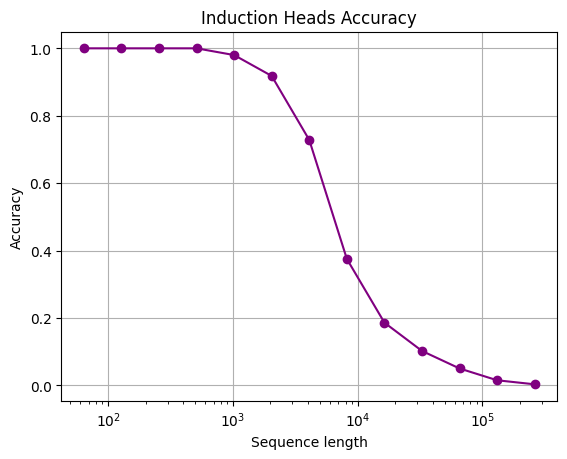

In [5]:
seq_len_list = [2**i for i in range(6, 6+len(accuracy))]
plt.plot(seq_len_list,accuracy, color = 'purple', marker = 'o')
plt.xscale('log')
plt.title('Induction Heads Accuracy')
plt.xlabel('Sequence length')
plt.ylabel('Accuracy')
plt.grid()

### Riproduco un suono che indica la fine del codice

In [6]:
from IPython.display import Audio, display
import numpy as np

# Parametri del suono
frequency = 1000
duration = 1
sampling_rate = 44100

token_id=-1
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
wave = 0.5 * np.sin(2 * np.pi * frequency * t)

display(Audio(wave, rate=sampling_rate, autoplay=True))